In [4]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [5]:
matches = pd.read_csv('../data/matches.csv')
balls = pd.read_csv('../data/deliveries.csv')

In [6]:
print("Matches shape:", matches.shape)
print("Balls shape:", balls.shape)
print("\n--- MATCHES COLUMNS ---")
print(matches.columns.tolist())
print("\n--- FIRST 3 ROWS ---")
matches.head(3)

Matches shape: (1095, 20)
Balls shape: (260920, 17)

--- MATCHES COLUMNS ---
['id', 'season', 'city', 'date', 'match_type', 'player_of_match', 'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner', 'result', 'result_margin', 'target_runs', 'target_overs', 'super_over', 'method', 'umpire1', 'umpire2']

--- FIRST 3 ROWS ---


,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar


In [7]:
print("=== MISSING VALUES IN MATCHES ===")
print(matches.isnull().sum()[matches.isnull().sum() > 0])

=== MISSING VALUES IN MATCHES ===
city                 51
player_of_match       5
winner                5
result_margin        19
target_runs           3
target_overs          3
method             1074
dtype: int64


In [8]:
matches['player_of_match'].fillna('Unknown', inplace=True)

0           BB McCullum
1            MEK Hussey
2           MF Maharoof
3            MV Boucher
4             DJ Hussey
             ...       
1090    Abhishek Sharma
1091           MA Starc
1092           R Ashwin
1093      Shahbaz Ahmed
1094           MA Starc
Name: player_of_match, Length: 1095, dtype: str

In [9]:
team_name_fix = {
    'Delhi Daredevils': 'Delhi Capitals',
    'Deccan Chargers': 'Sunrisers Hyderabad',
    'Pune Warriors': 'Rising Pune Supergiant',
    'Kings XI Punjab': 'Punjab Kings'
}
matches['team1'] = matches['team1'].replace(team_name_fix)
matches['team2'] = matches['team2'].replace(team_name_fix)
matches['winner'] = matches['winner'].replace(team_name_fix)
matches['toss_winner'] = matches['toss_winner'].replace(team_name_fix)

In [10]:
matches['season'] = pd.to_datetime(matches['date']).dt.year

print("\n✅ Cleaning done!")
print("Seasons covered:", sorted(matches['season'].unique()))


✅ Cleaning done!
Seasons covered: [np.int32(2008), np.int32(2009), np.int32(2010), np.int32(2011), np.int32(2012), np.int32(2013), np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024)]


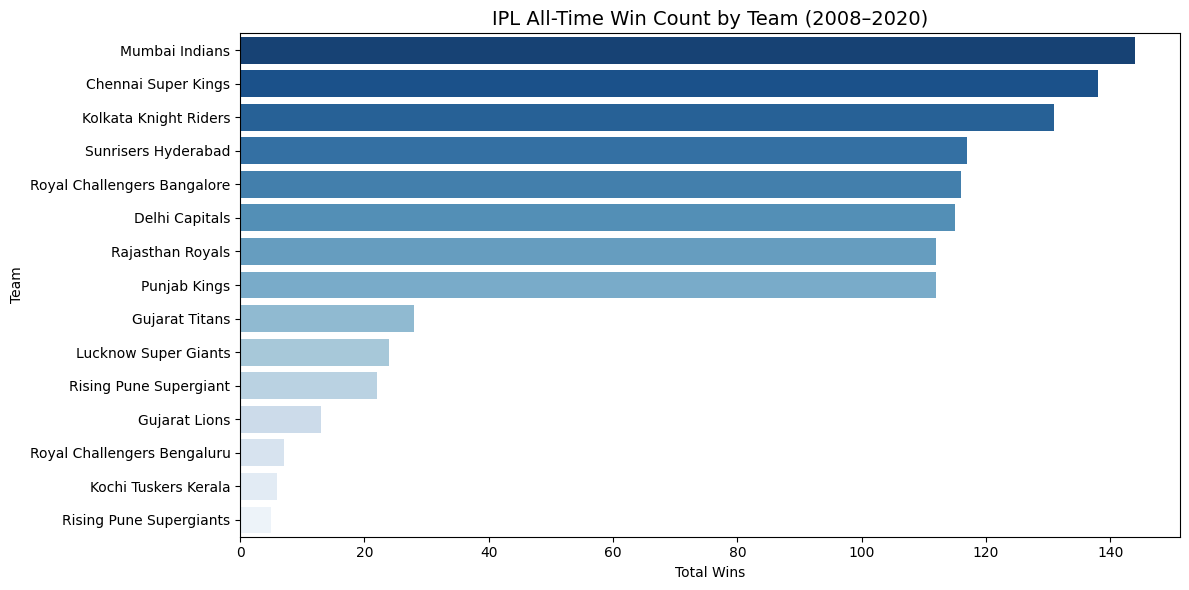

                           Team  Wins
0                Mumbai Indians   144
1           Chennai Super Kings   138
2         Kolkata Knight Riders   131
3           Sunrisers Hyderabad   117
4   Royal Challengers Bangalore   116
5                Delhi Capitals   115
6              Rajasthan Royals   112
7                  Punjab Kings   112
8                Gujarat Titans    28
9          Lucknow Super Giants    24
10       Rising Pune Supergiant    22
11                Gujarat Lions    13
12  Royal Challengers Bengaluru     7
13         Kochi Tuskers Kerala     6
14      Rising Pune Supergiants     5


In [11]:
win_counts = matches['winner'].value_counts().reset_index()
win_counts.columns = ['Team', 'Wins']

plt.figure(figsize=(12,6))
sns.barplot(data=win_counts, x='Wins', y='Team', palette='Blues_r')
plt.title('IPL All-Time Win Count by Team (2008–2020)', fontsize=14)
plt.xlabel('Total Wins')
plt.ylabel('Team')
plt.tight_layout()
plt.savefig('../outputs/01_team_wins.png', dpi=150)
plt.show()

print(win_counts)

In [12]:
# Toss winner = match winner?
matches['toss_match_win'] = matches['toss_winner'] == matches['winner']
toss_win_pct = matches['toss_match_win'].mean() * 100

print(f"✅ Toss winner also won the match: {toss_win_pct:.1f}% of the time")

# By toss decision
toss_decision = matches.groupby('toss_decision')['toss_match_win'].mean() * 100
print("\nWin % by toss decision:")
print(toss_decision.round(1))

✅ Toss winner also won the match: 50.6% of the time

Win % by toss decision:
toss_decision
bat      45.3
field    53.6
Name: toss_match_win, dtype: float64


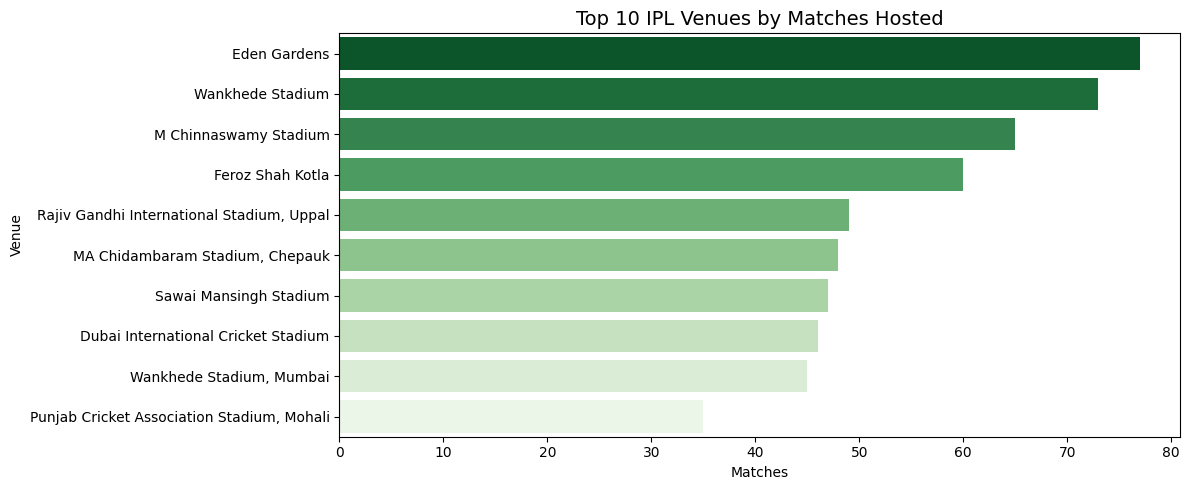

In [13]:
# Top venues by match count
venue_counts = matches['venue'].value_counts().head(10).reset_index()
venue_counts.columns = ['Venue', 'Matches']

plt.figure(figsize=(12,5))
sns.barplot(data=venue_counts, x='Matches', y='Venue', palette='Greens_r')
plt.title('Top 10 IPL Venues by Matches Hosted', fontsize=14)
plt.tight_layout()
plt.savefig('../outputs/02_top_venues.png', dpi=150)
plt.show()

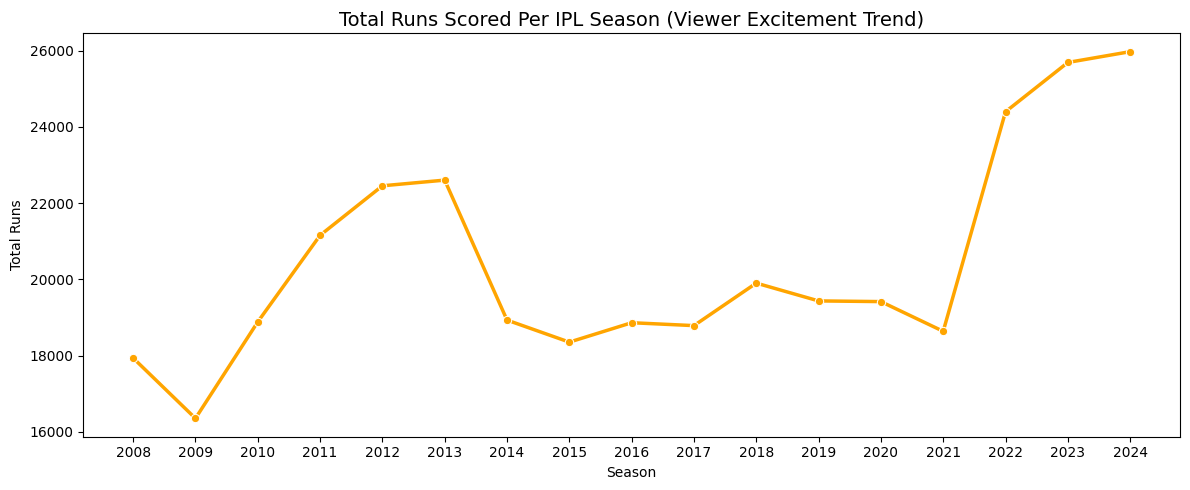

In [14]:
# Total runs per season = indicator of exciting cricket
season_runs = balls.merge(
    matches[['id','season']], left_on='match_id', right_on='id'
)
season_total = season_runs.groupby('season')['total_runs'].sum().reset_index()
season_total.columns = ['Season', 'Total_Runs']

plt.figure(figsize=(12,5))
sns.lineplot(data=season_total, x='Season', y='Total_Runs', marker='o', color='orange', linewidth=2.5)
plt.title('Total Runs Scored Per IPL Season (Viewer Excitement Trend)', fontsize=14)
plt.xlabel('Season')
plt.ylabel('Total Runs')
plt.xticks(season_total['Season'])
plt.tight_layout()
plt.savefig('../outputs/03_season_runs_trend.png', dpi=150)
plt.show()

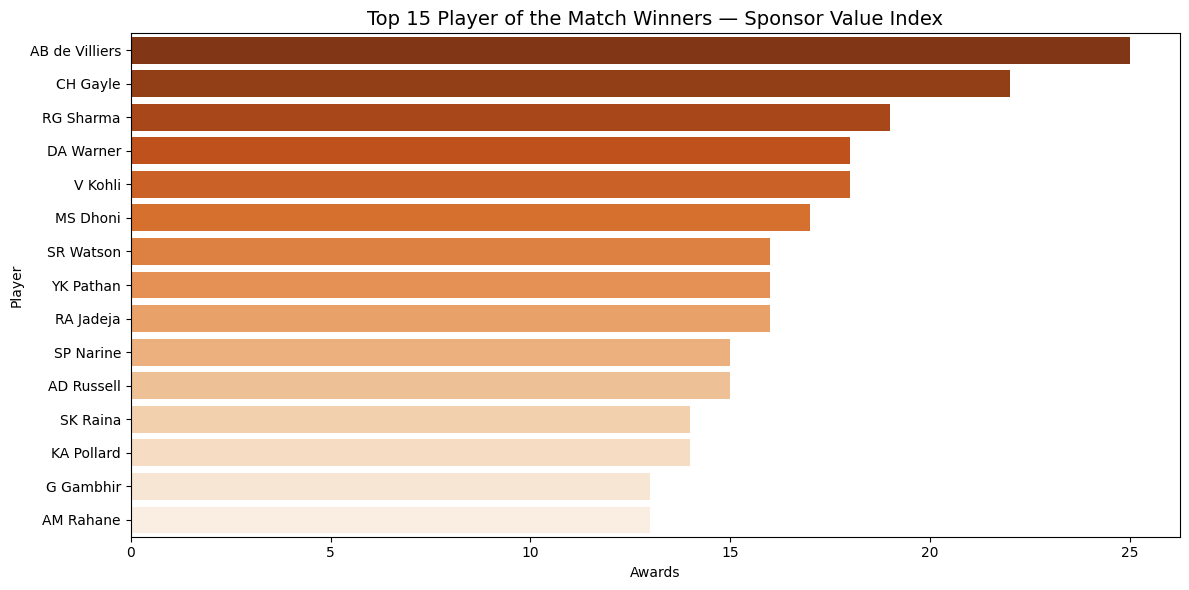

In [15]:
# Most impactful players = highest sponsor value
top_players = matches['player_of_match'].value_counts().head(15).reset_index()
top_players.columns = ['Player', 'Awards']

plt.figure(figsize=(12,6))
sns.barplot(data=top_players, x='Awards', y='Player', palette='Oranges_r')
plt.title('Top 15 Player of the Match Winners — Sponsor Value Index', fontsize=14)
plt.tight_layout()
plt.savefig('../outputs/04_top_players.png', dpi=150)
plt.show()

In [16]:
# Export cleaned matches file
matches.to_csv('../outputs/ipl_matches_clean.csv', index=False)

# Export season runs summary
season_total.to_csv('../outputs/ipl_season_runs.csv', index=False)

# Export win counts
win_counts.to_csv('../outputs/ipl_team_wins.csv', index=False)

# Export top players
top_players.to_csv('../outputs/ipl_top_players.csv', index=False)

print("✅ All files exported to outputs/ folder!")

✅ All files exported to outputs/ folder!
